In [1]:
# ---------IMPORTACIONES ----------------
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import psycopg2 
from sqlalchemy import create_engine

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11 
sns.set_theme(style='whitegrid')

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
# ── Conexión a PostgreSQL ─────────────────────────────────────
import sys
sys.path.append(r'C:\customer360\src')
from config import DB_CONFIG

# Conexión con SQLAlchemy para usar con pandas
engine = create_engine(
    f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@"
    f"{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)

print("Conexión establecida")

Conexión establecida


In [3]:
# ── Carga de datos desde el DW ────────────────────────────────

# Clientes
df_clientes = pd.read_sql("""
    SELECT * FROM dw.dim_cliente
""", engine)

# Transacciones
df_transacciones = pd.read_sql("""
    SELECT * FROM dw.fact_transacciones
""", engine)

# Préstamos
df_prestamos = pd.read_sql("""
    SELECT * FROM dw.fact_prestamos
""", engine)

# Pagos
df_pagos = pd.read_sql("""
    SELECT * FROM dw.fact_pagos
""", engine)

# Productos contratados
df_productos = pd.read_sql("""
    SELECT * FROM dw.fact_productos_contratados
""", engine)

print(f"Clientes:              {len(df_clientes):>8,}")
print(f"Transacciones:         {len(df_transacciones):>8,}")
print(f"Préstamos:             {len(df_prestamos):>8,}")
print(f"Pagos:                 {len(df_pagos):>8,}")
print(f"Productos contratados: {len(df_productos):>8,}")

Clientes:                 5,000
Transacciones:          148,212
Préstamos:                4,456
Pagos:                  345,861
Productos contratados:    9,424


In [4]:
# ── Exploración inicial de clientes ──────────────────────────

print("=== Primeras 5 filas ===")
print(df_clientes.head())

# Dimensiones 
print(f"\n=== Dimensiones ===")
print(f"Filas: {df_clientes.shape[0]:,} Columnas: {df_clientes.shape[1]}")

# Tipos de datos 
print("\n=== Tipos de datos ===")
print(df_clientes.dtypes)

# Valores nulos
print("\n=== Valores nulos ===")
print(df_clientes.isnull(). sum())

# Estadísticas descriptivas 
print("\n=== Estadística descriptivas ===")
print(df_clientes.describe())

=== Primeras 5 filas ===
   cliente_sk  cliente_id   nombre_completo  edad sexo estado_civil  \
0           9           9      Patricio Amo    57    M      Soltero   
1          10          10       Ruy Salgado    32    M      Soltero   
2          23          23    Evita Villegas    28    F  Conviviente   
3          32          32         Darío Hoz    53    M      Soltero   
4          56          56  Arturo Benavente    25    M   Divorciado   

       profesion  ingreso_mensual    ciudad        segmento_rfm  \
0      Ingeniero          1364.19  Huancayo                 NaN   
1     Empresario          2503.73  Arequipa                 NaN   
2  Independiente          1882.80      Lima                 NaN   
3         Médico          5493.75  Huancayo     Clientes Leales   
4        Docente          3161.39   Iquitos  Clientes Regulares   

   antiguedad_meses fecha_registro                fecha_carga  prob_churn  
0                24     2024-06-22 2026-06-28 16:57:12.401188        

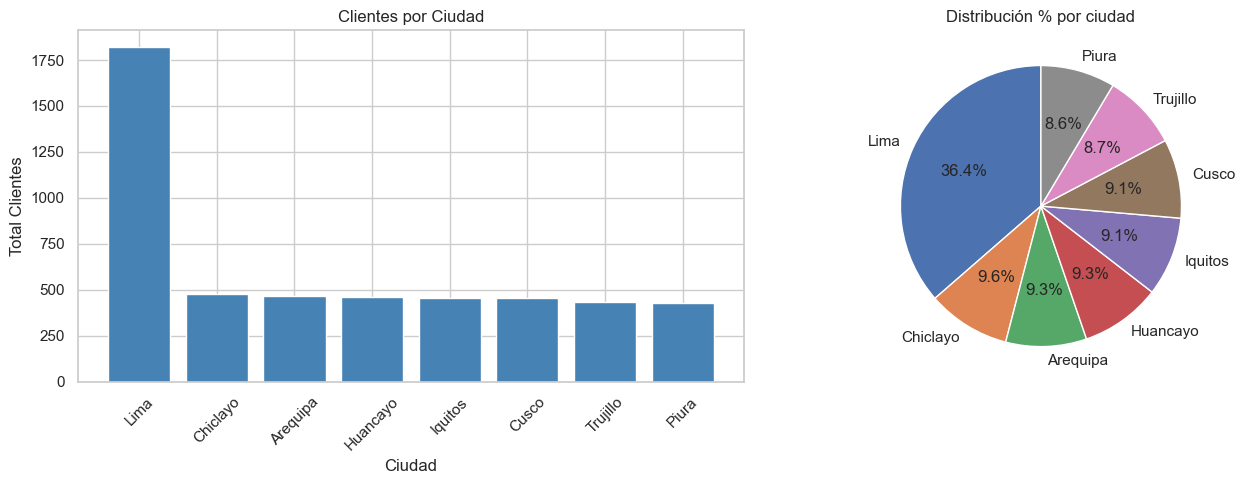

In [5]:
# ── Gráfico 1: Distribución de clientes por ciudad ────────────
fig, axes = plt.subplots(1, 2, figsize = (14,5))

# Gráfico de barras 
ciudad_counts = df_clientes['ciudad'].value_counts()
axes[0].bar(ciudad_counts.index, ciudad_counts.values, color='steelblue')
axes[0].set_title('Clientes por Ciudad')
axes[0].set_xlabel('Ciudad')
axes[0].set_ylabel('Total Clientes')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico de pastel
axes[1].pie(ciudad_counts.values, labels=ciudad_counts.index,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribución % por ciudad')

plt.tight_layout()
plt.savefig(r'C:\customer360\images\eda_clientes_ciudad.png', dpi=150, bbox_inches='tight')
plt.show()

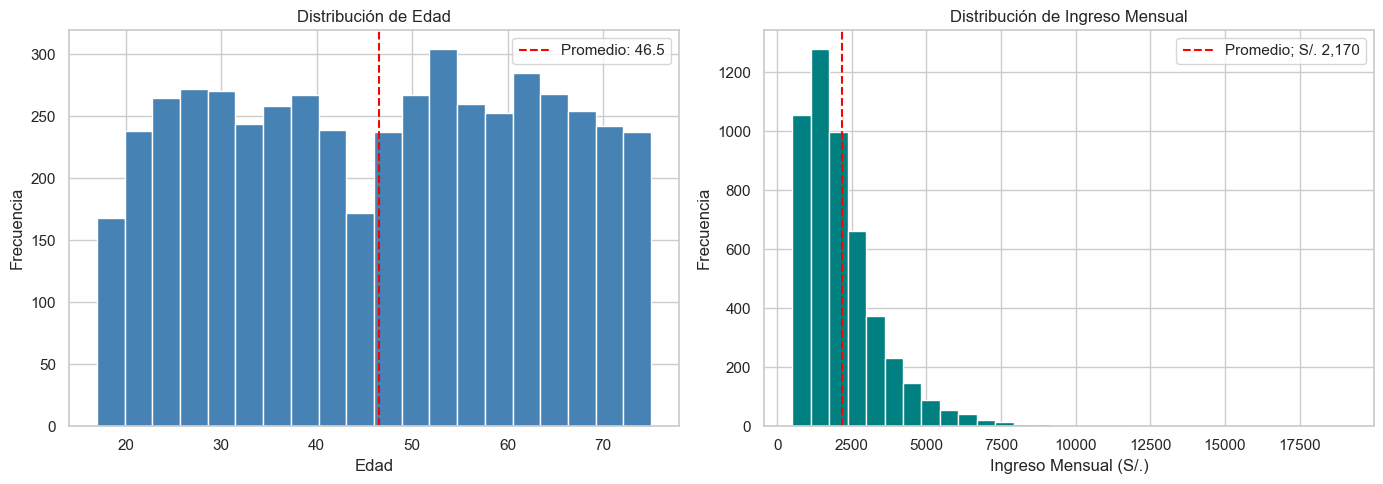

In [11]:
# ── Gráfico 2: Distribución de edad e ingreso mensual ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de edad 
axes[0].hist(df_clientes['edad'], bins=20, color='steelblue', edgecolor = 'white')
axes[0].set_title('Distribución de Edad')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df_clientes['edad'].mean(), color='red',
                linestyle='--', label=f"Promedio: {df_clientes['edad'].mean():.1f}")
axes[0].legend()

# Histograma de ingreso mensual
axes[1].hist(df_clientes['ingreso_mensual'], bins=30, color='teal', edgecolor='white')
axes[1].set_title('Distribución de Ingreso Mensual')
axes[1].set_xlabel('Ingreso Mensual (S/.)')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(df_clientes['ingreso_mensual'].mean(), color='red',
                linestyle='--', label=f"Promedio; S/. {df_clientes['ingreso_mensual'].mean():,.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\customer360\images\eda_edad_ingreso.png', dpi=150, bbox_inches='tight')
plt.show()

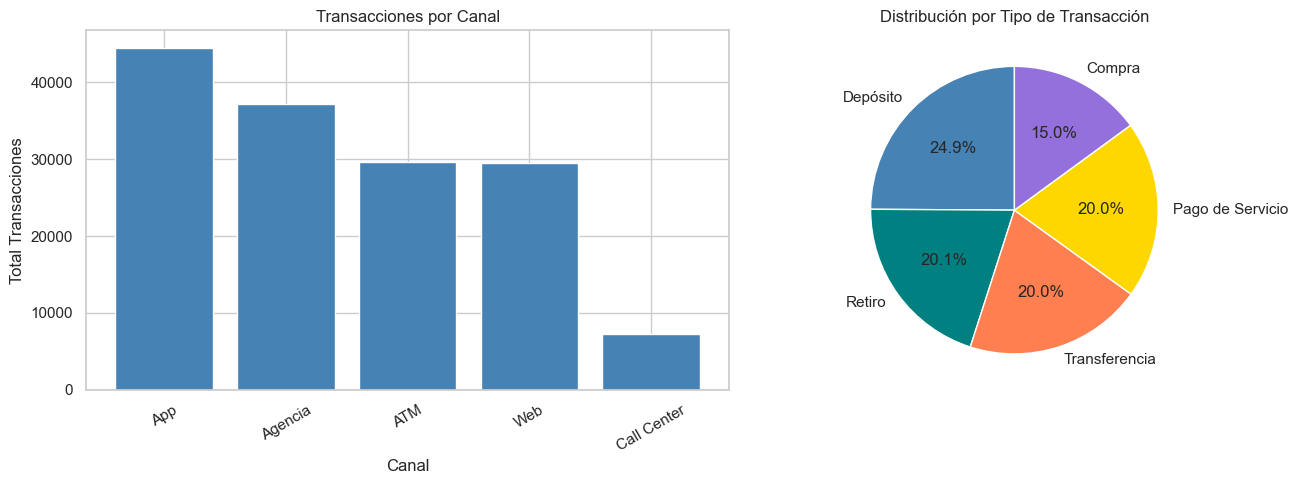

In [12]:
# ── Gráfico 3: Análisis de transacciones por canal y tipo ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transacciones por canal
df_canal = pd.read_sql("""
    SELECT ca.nombre AS canal,
            COUNT(t.transaccion_id) AS total,
            ROUND(SUM(t.monto)::numeric, 2) AS monto_total
    FROM dw.fact_transacciones t
    JOIN dw.dim_canal ca ON ca.canal_sk = t.canal_sk
    GROUP BY ca.nombre
    ORDER BY total DESC
""", engine)

axes[0].bar(df_canal['canal'], df_canal['total'], color='steelblue')
axes[0].set_title('Transacciones por Canal')
axes[0].set_xlabel('Canal')
axes[0].set_ylabel('Total Transacciones')
axes[0].tick_params(axis='x', rotation=30)

# Transacciones por tipo 
df_tipo = df_transacciones['tipo_transaccion'].value_counts()
axes[1].pie(df_tipo.values, labels=df_tipo.index,
            autopct='%1.1f%%', startangle=90,
            colors=['steelblue', 'teal', 'coral', 'gold', 'mediumpurple'])
axes[1].set_title('Distribución por Tipo de Transacción')

plt.tight_layout()
plt.savefig(r'C:\customer360\images\eda_transacciones_canal.png', dpi=150, bbox_inches='tight')
plt.show()

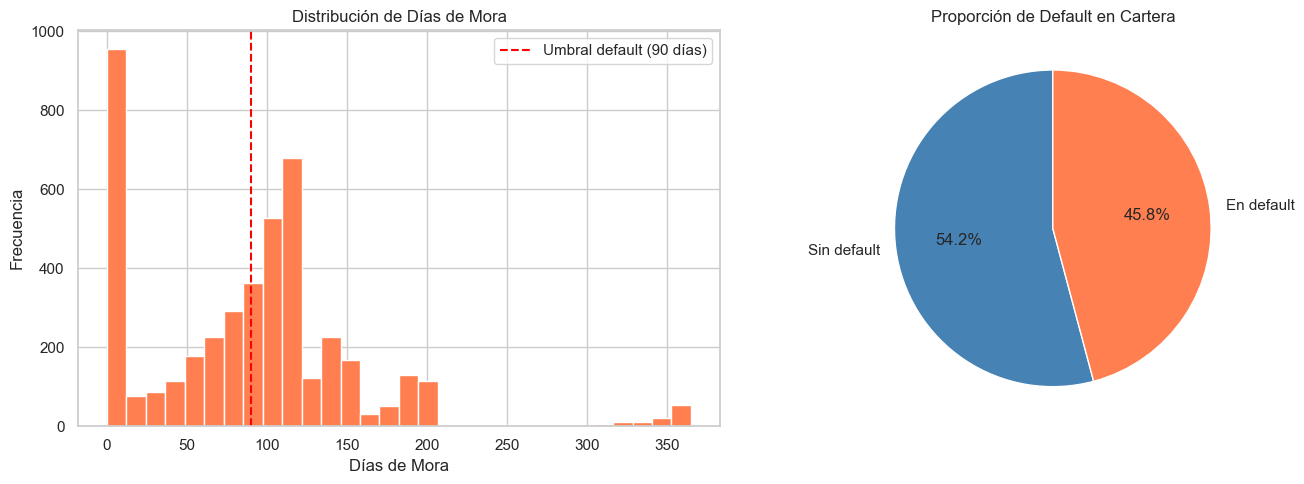

Total préstamos: 4,456
En default: 2,413
índice de morosidad: 54.15%
Monto en riesgo: S/. 95,445,599.54


In [13]:
# ── Gráfico 4: Análisis de riesgo crediticio ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de días de mora 
axes[0].hist(df_prestamos['max_dias_mora'], bins=30,
             color='coral', edgecolor='white')
axes[0].set_title('Distribución de Días de Mora')
axes[0].set_xlabel('Días de Mora')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(90, color='red', linestyle='--',
                label='Umbral default (90 días)')
axes[0].legend()

# Proporción de default vs no default
default_counts = df_prestamos['es_default'].value_counts()
labels = ['Sin default', 'En default']
colors = ['steelblue', 'coral']
axes[1].pie(default_counts.values, labels=labels,
            autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('Proporción de Default en Cartera')

plt.tight_layout()
plt.savefig(r'C:\customer360\images\eda_riesgo_crediticio.png', dpi=150, bbox_inches='tight')
plt.show()

# Estadísticas de riesgo
total = len(df_prestamos)
en_default = df_prestamos['es_default'].sum()
print(f"Total préstamos: {total:,}")
print(f"En default: {en_default:,}")
print(f"índice de morosidad: {en_default/total*100:.2f}%")
print(f"Monto en riesgo: S/. {df_prestamos[df_prestamos['es_default']==True]['monto'].sum():,.2f}")

=== Variables RFM calculadas ===
   cliente_sk  ultima_transaccion  frecuencia  monto_total
0           1                3083          29     21993.55
1           2                3096          41     39762.07
2           3                3061          19     10614.59
3           4                3099          26     10534.43
4           5                3074          11      6064.56
5           6                3090          24      9384.52
6           7                3093          19      8091.43
7           8                3055          23     12388.89
8          11                3098          33     13446.95
9          12                3096          17     10661.08

Dimensiones: (4868, 4)

Estadísticas:
        frecuencia    monto_total
count  4868.000000    4868.000000
mean     30.446179   20582.186964
std      14.407773   13153.619672
min       6.000000    1616.240000
25%      19.000000   10830.657500
50%      26.000000   17237.045000
75%      40.000000   27007.627500
max    

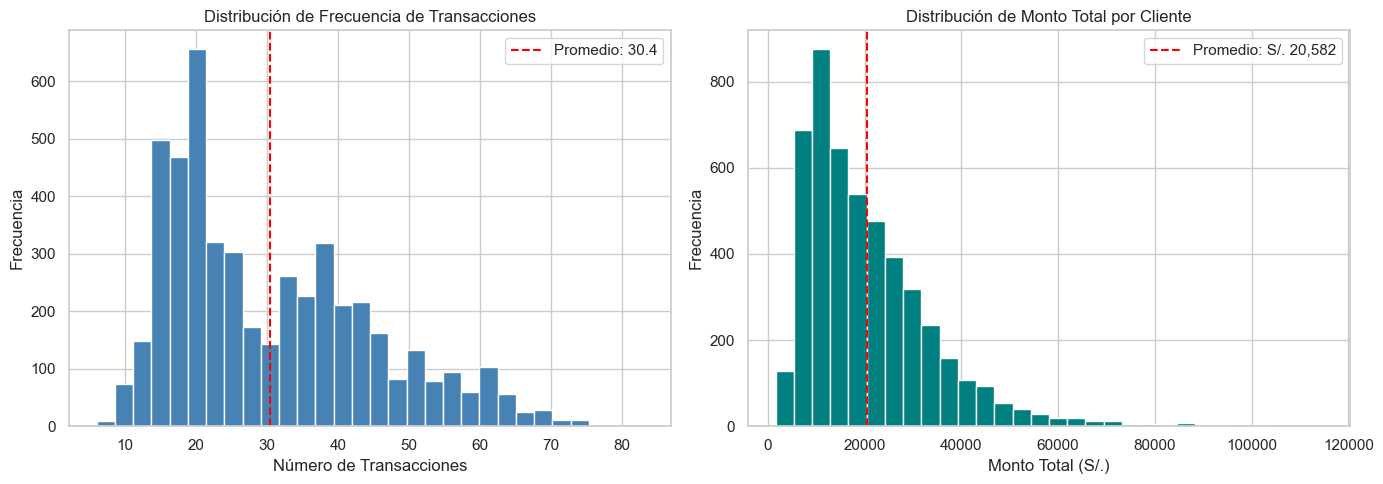

In [14]:
# ── Gráfico 5: Ingeniería de Variables RFM ────────────────────

# Calcular RFM por cliente
hoy = pd.Timestamp.today()

# Recencia: días desde la última transacción
df_recencia = df_transacciones.groupby('cliente_sk').agg(
    ultima_transaccion=('fecha_sk', 'max')
).reset_index()

# Frecuencia: número de transacciones por cliente
df_frecuencia = df_transacciones.groupby('cliente_sk').agg(
    frecuencia=('transaccion_id', 'count')
).reset_index()

# Monto: total gastado por cliente
df_monto = df_transacciones.groupby('cliente_sk').agg(
    monto_total=('monto', 'sum')
).reset_index()

# Unir todo
df_rfm = df_recencia.merge(df_frecuencia, on='cliente_sk')
df_rfm = df_rfm.merge(df_monto, on='cliente_sk')

print("=== Variables RFM calculadas ===")
print(df_rfm.head(10))
print(f"\nDimensiones: {df_rfm.shape}")
print(f"\nEstadísticas:")
print(df_rfm[['frecuencia','monto_total']].describe())

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de frecuencia
axes[0].hist(df_rfm['frecuencia'], bins=30,
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Frecuencia de Transacciones')
axes[0].set_xlabel('Número de Transacciones')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df_rfm['frecuencia'].mean(), color='red',
                linestyle='--',
                label=f"Promedio: {df_rfm['frecuencia'].mean():.1f}")
axes[0].legend()

# Distribución de monto total
axes[1].hist(df_rfm['monto_total'], bins=30,
             color='teal', edgecolor='white')
axes[1].set_title('Distribución de Monto Total por Cliente')
axes[1].set_xlabel('Monto Total (S/.)')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(df_rfm['monto_total'].mean(), color='red',
                linestyle='--',
                label=f"Promedio: S/. {df_rfm['monto_total'].mean():,.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\customer360\images\eda_variables_rfm.png', dpi=150, bbox_inches='tight')
plt.show()

DataFrame de análisis: (4868, 9)
   cliente_sk  edad  ingreso_mensual  antiguedad_meses  frecuencia  \
0          32    53          5493.75                22          37   
1          56    25          3161.39                 1          19   
2          57    31          1092.77                74          50   
3          58    75          1501.88                89          17   
4          59    39          2205.61                16          17   

   monto_total  total_prestamos  max_mora  tasa_default  
0     17775.84              0.0       0.0           0.0  
1      9138.82              0.0       0.0           0.0  
2     30643.40              1.0     118.0           1.0  
3     10109.80              1.0     102.0           1.0  
4     18481.29              1.0       0.0           0.0  


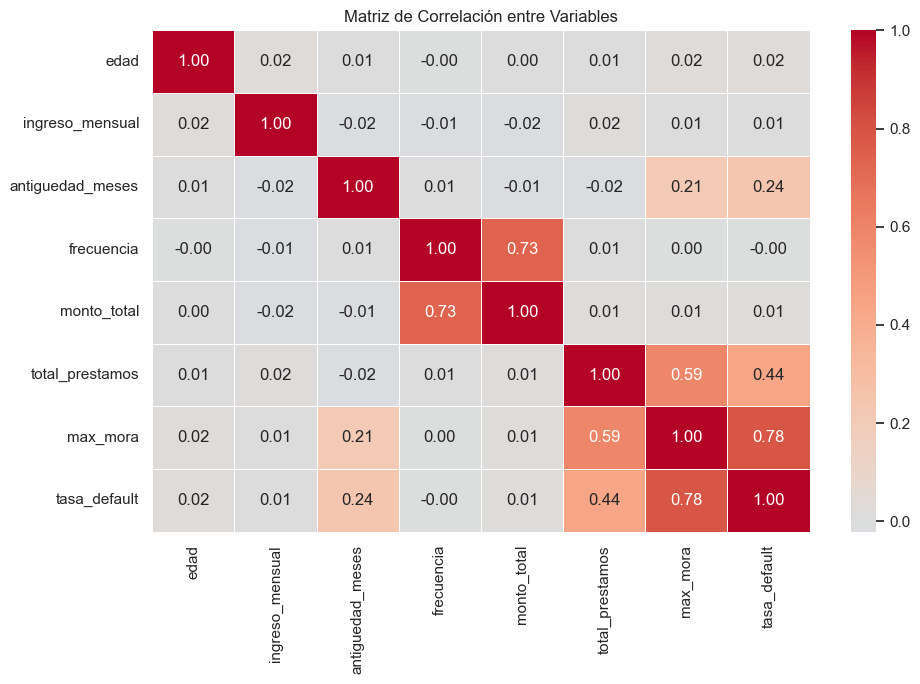

In [15]:
# ── Gráfico 6: Correlación entre variables numéricas ──────────

# Construir DataFrame con variables relevantes por cliente
df_analisis = df_clientes[['cliente_sk', 'edad', 'ingreso_mensual',
                           'antiguedad_meses']].merge(
    df_rfm[['cliente_sk', 'frecuencia', 'monto_total']], on='cliente_sk'
).merge(
    df_prestamos.groupby('cliente_sk').agg(
        total_prestamos=('prestamo_id', 'count'),
        max_mora = ('max_dias_mora', 'max'),
        tasa_default = ('es_default', 'mean')
    ).reset_index(), on='cliente_sk', how='left'
)

# Rellenar nuos de clientes sin préstamos 
df_analisis['total_prestamos'] = df_analisis['total_prestamos'].fillna(0)
df_analisis['max_mora'] = df_analisis['max_mora'].fillna(0)
df_analisis['tasa_default'] = df_analisis['tasa_default'].fillna(0)

print(f"DataFrame de análisis: {df_analisis.shape}")
print(df_analisis.head())

# Matriz de correlación
fig, ax = plt.subplots(figsize=(10, 7))

variables = ['edad', 'ingreso_mensual', 'antiguedad_meses',
             'frecuencia', 'monto_total', 'total_prestamos',
             'max_mora', 'tasa_default']

corr_matrix = df_analisis[variables].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlación entre Variables')

plt.tight_layout()
plt.savefig(r'C:\customer360\images\eda_matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()